In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import linregress

In [2]:
np.random.seed(1)

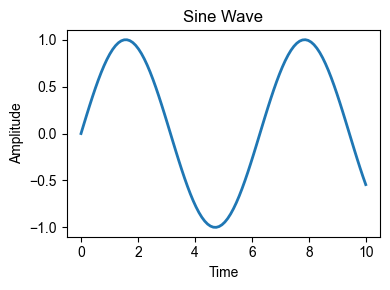

In [11]:
# Lets Create a default template appropriate for publications.

# Choosing style.
plt.rcParams.update({
    "font.family":"Arial",
    "font.size":10,
    "axes.labelsize":10,
    "axes.titlesize":12,
    "legend.fontsize":8
})

# Creating a small simple example data.
x = np.linspace(0,10,100)
y = np.sin(x)

# Creating figure.
fig, ax = plt.subplots(
    figsize=(4,3)
)

# Creating plot.
ax.plot(
    x,
    y,
    linewidth=2
)

ax.set_title("Sine Wave")
ax.set_xlabel("Time")
ax.set_ylabel("Amplitude")

fig.tight_layout()

plt.show()

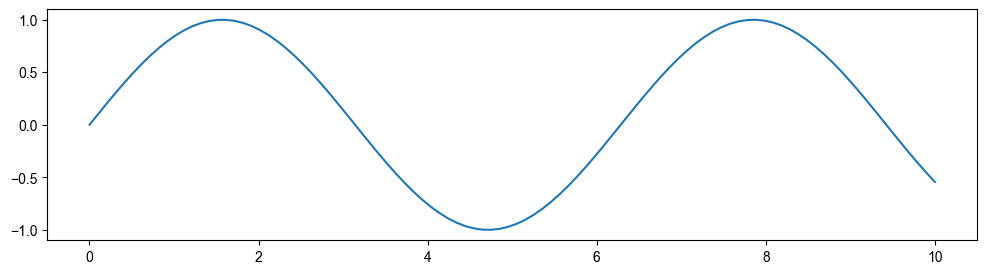

None


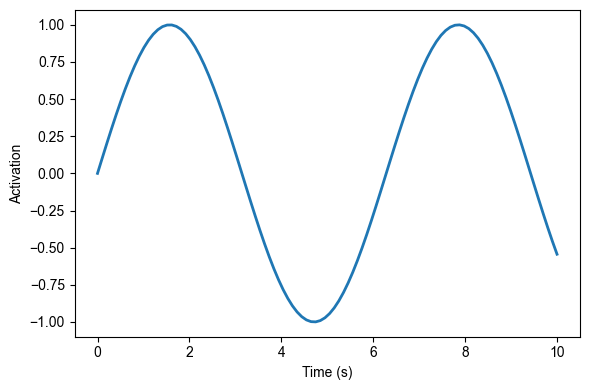

None


In [10]:
# Let's improve a poor figure.

# Poor figure:
plt.figure(figsize=(12,3))
plt.plot(x,y)

print(plt.show())

# Improved version:
plt.figure(figsize=(6,4))
plt.plot(
    x,
    y,
    linewidth=2
)
plt.xlabel("Time (s)")
plt.ylabel("Activation")
plt.tight_layout() # Automatically adjusts spacing around elements.

print(plt.show())

Note: for exporting figures there are three main formats.

> fig.savefig("figure.png", dpi=600)

> fig.savefig("figure.pdf")

> fig.savefig("figure.svg")

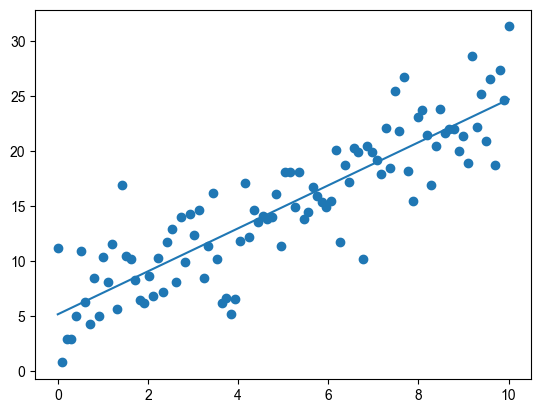

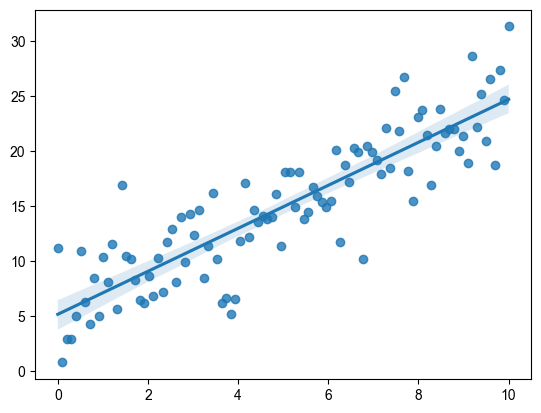

In [16]:
# Simulating Noisy Data.

x = np.linspace(0, 10, 100)
y = 2*x + 5 + np.random.normal(loc=0, scale=3, size=len(x))
# The relationship is y = 2x + 5.

# Creatin a plot without uncertainty (scipy).

slope, intercept, *_ = linregress(x, y)

y_pred = slope*x + intercept

plt.scatter(x, y)

plt.plot(x, y_pred)

plt.show() # The regression line appears exact but it is not.

# Creating a plot with confidence band (seaborn).

sns.regplot(
    x=x,
    y=y
)

plt.show() # Narrow band means high confidence. Wide band means low confidence

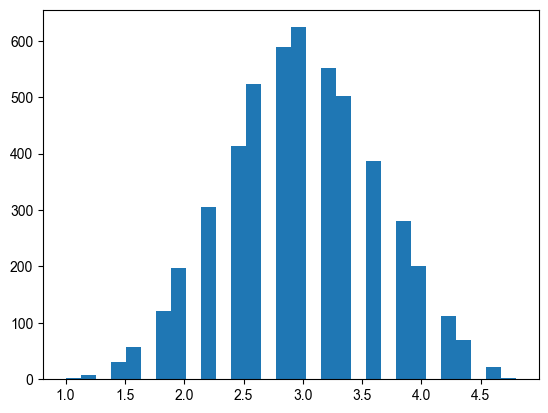

In [17]:
# Creating a mini dataset to show booststrap mean distribution.
data = [1,2,3,4,5]

boot_means = []

for _ in range(5000):
    sample = np.random.choice(
        data,
        size=len(data),
        replace=True
    )

    boot_means.append(
        np.mean(sample)
    )

plt.hist(
    boot_means,
    bins=30
)

plt.show()

1.8 4.2


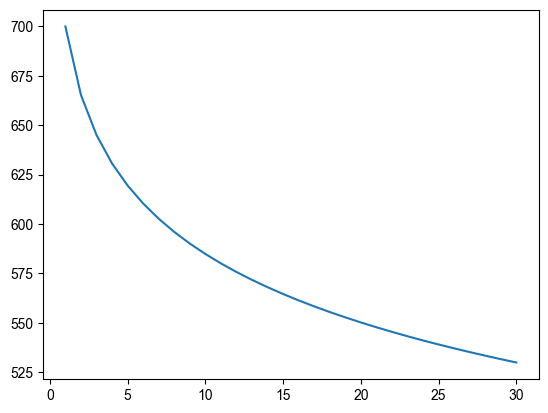

None


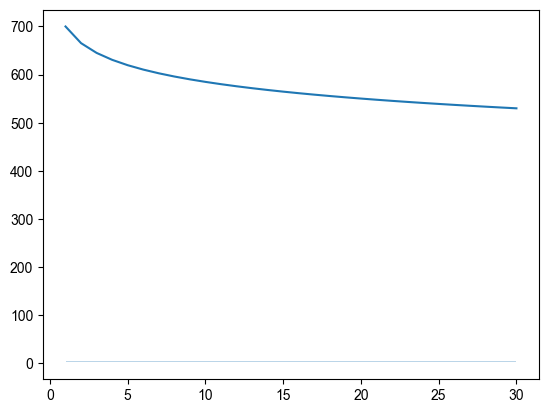

None


In [20]:
# Showing bootstrap confidence interval.

trials = np.arange(1, 31)

mean_rt = (
    700
    - 50*np.log(trials)
)

lower = np.percentile(
    boot_means,
    2.5
)

upper = np.percentile(
    boot_means,
    97.5
)

print(lower, upper)

# Comparing with and without uncertainty.

plt.plot(
    trials,
    mean_rt
)

print(plt.show())

# Improving the figure.

plt.plot(
    trials,
    mean_rt
)

plt.fill_between(
    trials,
    lower,
    upper,
    alpha=0.3
)

print(plt.show())